# 61 · Gulf of Trieste map design

A plotting workspace for the spatial figure in **plot_design_report_gulf_of_trieste.pdf**, section 1 (with the caption guidance in section 3), updated using **2_gulf_of_trieste_map_todo.pdf**.

**(a) Observed AIS counts → (b) Predicted mean AIS counts → (c) Prediction residuals (predicted − observed).**

This notebook reads the saved final predictions from the two selected **LGCP confidence-redistribution** experiment runs (May 5–11 and November 3–9, 2025). It does not train models, run inference, or load the full training dataset. The preview day is controlled by `DATE` below; it is an editable design example, not a claim that this is the most representative day.

**Working loop**
1. Run all cells once to load the saved data and see the initial figure.
2. For colours, labels, sizing, or support markers, edit **Style and preview** and rerun that cell only.
3. For a different model/day or interpolation, edit **Select data and prepare surfaces**, then rerun it and the preview.
4. Enable **Export** when ready to save PNG/PDF/SVG, the source cell values, settings, and caption.

Land/coastline context now comes from Eurostat GISCO geometry; the coloured model support is separately derived from retained cells. All design-specific code stays here while we iterate. The existing grid-surface helper is reused unchanged. The PDF's secondary agreement/hexbin plot is outside this notebook's scope.

## Setup
Run from the repository root or `notebooks/`. Saved predictions and the small bundled GIS/grid snapshots are sufficient; no model execution, full training dataset, network connection, or runtime PDF access is needed.

In [108]:
%matplotlib inline
from pathlib import Path
from time import perf_counter
import json
import sys

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize, TwoSlopeNorm
from matplotlib.path import Path as MplPath
from matplotlib.patches import PathPatch, Patch
from matplotlib.lines import Line2D
import geopandas as gpd
import shapely
from shapely.geometry import box, Point
from shapely.geometry.polygon import orient
from scipy.spatial import cKDTree
from pyproj import Transformer
from matplotlib.ticker import FuncFormatter, MaxNLocator
import numpy as np
import pandas as pd
from IPython.display import display, Markdown

PROJECT_ROOT = next(
    (p for p in [Path.cwd().resolve(), *Path.cwd().resolve().parents]
     if (p / "src/visualization/grid_surface.py").is_file()),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Open this notebook from the AIPS repository root or notebooks/.")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
from src.visualization.grid_surface import complete_grid_surface

EXPERIMENT_ROOT = PROJECT_ROOT / "reports/experiments/final_experiments"
RUN_DIRS = {
    "may": EXPERIMENT_ROOT / "may_5_11/1_week/2024+2025_may_5_11_confidence_redistribute_original_setting_20260920-180732",
    "november": EXPERIMENT_ROOT / "november_3_9/1_week/2024+2025_nov_3_9_confidence_redistribute_original_setting_20260920-180347",
}
ASSET_DIR = PROJECT_ROOT / "notebooks/assets/map_design_61"
GIS_FILE = ASSET_DIR / "gisco_2024_01m_gulf_countries.geojson"
GRID_FILE = ASSET_DIR / "retained_grid_centres.csv"
MARITIME_FILE = ASSET_DIR / "marine_regions_gulf_boundaries.geojson"
SLOVENIAN_WATERS_FILE = ASSET_DIR / "marine_regions_slovenian_waters.geojson"
ITALIAN_WATERS_FILE = ASSET_DIR / "marine_regions_italian_waters.geojson"
MARITIME_SOURCE = json.loads((ASSET_DIR / "maritime_sources.json").read_text())
GEOGRAPHY_SOURCE = json.loads((ASSET_DIR / "sources.json").read_text())
retained_grid = pd.read_csv(GRID_FILE)
if retained_grid.duplicated(["longitude", "latitude"]).any() or not np.isfinite(retained_grid.to_numpy()).all():
    raise ValueError("The retained-grid snapshot must contain unique finite centres.")
grid_tree = cKDTree(retained_grid[["longitude", "latitude"]].to_numpy())
EXPORT_DIR = PROJECT_ROOT / "reports/paper/map_design_61"
METHOD_LABELS = {"lgcp": "LGCP (confidence redistribution)"}

## Load saved values once
Load `spatial_predictions.csv` from exactly these two runs:

- **May:** `2024+2025_may_5_11_confidence_redistribute_original_setting_20260920-180732`
- **November:** `2024+2025_nov_3_9_confidence_redistribute_original_setting_20260920-180347`

These files store the **final predictions after confidence redistribution**. They replace the earlier notebook-54 inputs in this workspace. Every day from **2025-05-05 through 2025-05-11** and **2025-11-03 through 2025-11-09** is available; the selected date determines which run is used.

Saved standardized coordinates are first inverted with their plotting metadata, then matched to the **original retained cell centres** in the local grid snapshot. Matching must be within 0.0001 degrees and duplicates are rejected. The small legacy scaling discrepancy therefore does not shift the grid relative to the GIS coastline. Counts and final predictions are unchanged.

The inventory reports the loaded dates and cell totals. Source run names and CSV paths are retained in the cell data and exports. An unavailable date raises an error rather than recomputing predictions.

In [109]:
required = {"date", "x", "y", "observed", "predicted",
            "lon_mean", "lon_std", "lat_mean", "lat_std"}
source_files = []
frames = []
for period, run_dir in RUN_DIRS.items():
    path = run_dir / "spatial_predictions.csv"
    if not path.is_file():
        raise FileNotFoundError(f"Missing saved predictions: {path}")
    saved = pd.read_csv(path)
    missing = required - set(saved.columns)
    if missing:
        raise ValueError(f"{path}: missing columns {sorted(missing)}")
    if saved.empty:
        raise ValueError(f"{path}: no saved prediction rows")
    numeric = sorted(required - {"date"})
    saved[numeric] = saved[numeric].apply(pd.to_numeric, errors="raise")
    if not np.isfinite(saved[numeric].to_numpy()).all():
        raise ValueError(f"{path}: nonfinite coordinates, counts, or metadata")
    if (saved[["lon_std", "lat_std"]] <= 0).any().any():
        raise ValueError(f"{path}: coordinate scales must be positive")
    if (saved[["lon_mean", "lon_std", "lat_mean", "lat_std"]].nunique() != 1).any():
        raise ValueError(f"{path}: inconsistent coordinate metadata within one run")
    frame = saved.rename(columns={"observed": "y_true", "predicted": "y_pred"}).copy()
    frame["longitude"] = frame["x"] * frame["lon_std"] + frame["lon_mean"]
    frame["latitude"] = frame["y"] * frame["lat_std"] + frame["lat_mean"]
    # Legacy saved plotting metadata differs slightly from the training scaler.
    # Match to the original grid with a strict tolerance; never move a count to a different cell.
    approximate = frame[["longitude", "latitude"]].to_numpy()
    distances, indices = grid_tree.query(approximate)
    if distances.max() > 0.0001:
        raise ValueError(f"{path}: saved positions do not match the original retained grid within 0.0001 degrees")
    frame["longitude_saved_plot"] = frame["longitude"]
    frame["latitude_saved_plot"] = frame["latitude"]
    frame[["longitude", "latitude"]] = retained_grid.iloc[indices][["longitude", "latitude"]].to_numpy()
    frame["method"] = "lgcp"
    frame["period"] = period
    frame["source_run"] = run_dir.name
    frame["source_csv"] = str(path.relative_to(PROJECT_ROOT))
    frames.append(frame)
    source_files.append(path)
    print(f"{period.capitalize()}: {run_dir.name}")
predictions = pd.concat(frames, ignore_index=True)
predictions["date"] = pd.to_datetime(predictions["date"], errors="raise").dt.normalize()
if predictions[["method", "date"]].isna().any().any():
    raise ValueError("Every saved row needs a model and date.")
numeric_columns = ["longitude", "latitude", "y_true", "y_pred"]
predictions[numeric_columns] = predictions[numeric_columns].apply(pd.to_numeric, errors="raise")
if not np.isfinite(predictions[numeric_columns].to_numpy()).all():
    raise ValueError("Coordinates and counts must be finite.")
if (predictions[["y_true", "y_pred"]] < 0).any().any():
    raise ValueError("Observed and predicted counts must be nonnegative.")
cell_key = ["method", "date", "longitude", "latitude"]
if predictions.duplicated(cell_key).any():
    raise ValueError("Duplicate model/date/cell rows: resolve overlapping exports before plotting.")

inventory = predictions.groupby(["period", "method", "date"]).agg(
    cells=("y_true", "size"), observed_total=("y_true", "sum"),
    predicted_total=("y_pred", "sum"),
).reset_index()
display(inventory)
print(f"Loaded {len(source_files)} files, {len(predictions):,} cell-day/model rows.")

May: 2024+2025_may_5_11_confidence_redistribute_original_setting_20260920-180732
November: 2024+2025_nov_3_9_confidence_redistribute_original_setting_20260920-180347


,period,method,date,cells,observed_total,predicted_total
0,may,lgcp,2025-05-05,49,0,15.019308
1,may,lgcp,2025-05-06,49,19,15.656604
2,may,lgcp,2025-05-07,49,37,15.989074
3,may,lgcp,2025-05-08,49,32,16.020370
4,may,lgcp,2025-05-09,49,28,13.381401
5,may,lgcp,2025-05-10,49,0,0.000000
6,may,lgcp,2025-05-11,49,11,0.000000
7,november,lgcp,2025-11-03,49,19,10.092131
8,november,lgcp,2025-11-04,49,28,15.795826
9,november,lgcp,2025-11-05,49,21,13.813248


Loaded 2 files, 686 cell-day/model rows.


## Geographic context and model support

The bundled land polygons come from [Eurostat GISCO Countries 2024, 1:1 million](https://gisco-services.ec.europa.eu/distribution/v2/countries/countries-2024-units.html). GeoPandas clips the local Italy/Slovenia/Croatia subset to the shared extent below. Sources, checksums and reproduction notes are in `notebooks/assets/map_design_61/`. Figures and export captions include the source credit: **© EuroGeographics for the administrative boundaries**. GISCO requests that credit on the publication's introductory page too; see the [source's use conditions](https://ec.europa.eu/eurostat/web/gisco/geodata/administrative-units).

The support footprint is the union of one rectangular grid cell around every original retained centre (half a grid spacing on each side), intersected with water. This is a transparent **display-support convention**, not a coastline or a national/maritime jurisdiction. The grid snapshot is identical in the 2024 and 2025 processed datasets. GISCO country boundaries are drawn on land only; a separate published maritime layer supplies sea divisions. Labels identify Italy and Slovenia explicitly; water outside retained support matches the darkest colour of the count grid. It is background only, not an inferred zero count; the dashed edge still identifies model coverage.

The GIS layer is generalized geographic context, so finer harbour or coastal details may require a higher-resolution coastline in a later iteration. The current study-area polygon is not treated as authoritative coast geometry.

A coarse coastal cell can have its centre on GIS land (one of the 49 centres in this subset). Its original counts and cell footprint are retained; only the water part can be coloured. The `show_support=True` overlay exposes this alignment directly.

The western and southern map limits are computed from the leftmost and lowest retained cell edges (centre minus half a grid spacing), aligning the vertical and horizontal axes with the model grid.

The optional **maritime lines** come from [Marine Regions / VLIZ, v12](https://www.marineregions.org/downloads.php) ([CC BY](https://www.marineregions.org/disclaimer.php)); `maritime_sources.json` records the exact request and feature IDs. Italy's two bilateral lines are classified as treaty boundaries. The dashed Slovenia–Croatia line follows the [2017 arbitral award](https://pca-cpa.org/en/cases/3/), which [Croatia does not accept](https://mvep.gov.hr/pm-plenkovic-arbitral-award-does-not-in-any-way-bind-croatia-and-croatia-shall-not-implement-it/195887). The map identifies this distinction rather than presenting all lines as agreed boundaries. Joint-regime limits and straight baselines are omitted. No lines are inferred, extended or geometrically smoothed; soft styling changes their appearance only.


The Slovenian-water display mask uses the same provider’s [Slovenia polygon, MRGID 5692](https://www.marineregions.org/eezdetails.php?mrgid=5692), intersected with GIS water. It is bundled locally with its source request and checksum. The original retained-support mask is preserved separately, so the exclusion can be toggled without recomputing or changing predictions.

In [110]:
# One common geographic context for every day, model panel, and interval preview.
COUNTRY_LABELS = {"Italy": (13.35, 45.79), "Slovenia": (13.81, 45.57), "Croatia": (13.70, 45.45)}
SUPPORT_NOTE = ("Model values are shown only over retained support; "
                "sea outside it is background, not a zero-valued prediction.")


def grid_axis(values):
    unique = np.unique(np.asarray(values, dtype=float))
    if len(unique) < 2:
        raise ValueError("At least two retained coordinates per axis are required.")
    indices = np.rint((unique - unique[0]) / np.diff(unique).min()).astype(int)
    step = (unique[-1] - unique[0]) / indices[-1]
    if not np.allclose(unique, unique[0] + indices * step, atol=step * 0.002, rtol=0):
        raise ValueError("Retained cell centres must belong to a regular grid.")
    edges = unique[0] - step / 2 + np.arange(indices[-1] + 2) * step
    return unique[0], step, edges


# Align both axes to the outer western and southern cell edges, not the cell centres.
GRID_WEST = float(grid_axis(retained_grid.longitude)[2][0])
GRID_SOUTH = float(grid_axis(retained_grid.latitude)[2][0])
# west, south, east, north; lies within the bundled GIS subset.
MAP_EXTENT = (GRID_WEST, GRID_SOUTH, 13.90, 45.84)


def make_geography(grid, extent):
    west, south, east, north = extent
    if not (west < east and south < north):
        raise ValueError("MAP_EXTENT must be (west, south, east, north).")
    available = box(*GEOGRAPHY_SOURCE["clip_bounds_west_south_east_north"])
    view = box(*extent)
    if not available.covers(view):
        raise ValueError("MAP_EXTENT exceeds the bundled GIS subset; obtain a wider subset first.")
    countries = gpd.clip(gpd.read_file(GIS_FILE).to_crs(4326), view)
    land = countries.geometry.union_all()
    water = view.difference(land)
    slovenian_waters = gpd.read_file(SLOVENIAN_WATERS_FILE).to_crs(4326).geometry.union_all().intersection(water)
    italian_waters = gpd.read_file(ITALIAN_WATERS_FILE).to_crs(4326).geometry.union_all().intersection(water)
    maritime_lines = gpd.read_file(MARITIME_FILE).to_crs(4326)
    maritime_lines["geometry"] = maritime_lines.geometry.intersection(water)
    maritime_lines = maritime_lines.loc[~maritime_lines.geometry.is_empty].copy()
    x0, dx, xe = grid_axis(grid.longitude)
    y0, dy, ye = grid_axis(grid.latitude)
    ix = np.rint((grid.longitude.to_numpy() - x0) / dx).astype(int)
    iy = np.rint((grid.latitude.to_numpy() - y0) / dy).astype(int)
    # Shared edges avoid tiny artificial gaps from floating-point coordinate rounding.
    footprints = shapely.union_all([
        box(xe[i], ye[j], xe[i + 1], ye[j + 1]) for i, j in zip(ix, iy)
    ])
    support = footprints.intersection(water)
    if support.is_empty:
        raise ValueError("No retained model support intersects water in this extent.")
    national_lines = []
    geoms = countries.geometry.tolist()
    for i, a in enumerate(geoms):
        for b in geoms[i + 1:]:
            line = a.boundary.intersection(b.boundary)
            if line.length > 0:
                national_lines.append(line)
    return dict(
        extent=tuple(extent), countries=countries, land=land, water=water,
        footprints=footprints, support=support,
        slovenian_waters=slovenian_waters, italian_waters=italian_waters,
        support_without_slovenia=support.difference(slovenian_waters),
        # Remove artificial edges introduced by clipping the GIS layer to the frame.
        coastline=land.boundary.difference(view.boundary),
        national_borders=shapely.union_all(national_lines),
        maritime_lines=maritime_lines,
        support_edge=footprints.boundary.intersection(water).difference(view.boundary),
        grid=grid.copy(), cell_spacing=(dx, dy),
    )


geography = make_geography(retained_grid, MAP_EXTENT)
land_centres = shapely.intersects_xy(geography["land"], retained_grid.longitude, retained_grid.latitude)
print(f"GIS context: Eurostat GISCO {GEOGRAPHY_SOURCE['version']}; {len(retained_grid)} retained centres.")
print(f"Retained centres falling on GIS land: {int(land_centres.sum())}; land pixels are always masked.")
print("Display support = retained cell footprints intersected with water; maritime context uses published source lines.")

GIS context: Eurostat GISCO 2024; 49 retained centres.
Retained centres falling on GIS land: 1; land pixels are always masked.
Display support = retained cell footprints intersected with water; maritime context uses published source lines.


## Surface preparation and figure helpers

The existing **complete-grid diffusion + PCHIP display interpolation** remains unchanged. Its temporary zero-filled rectangular grid is only an interpolation device. After interpolation, a common mask limits all fields to **retained grid-cell footprints intersected with GIS water**. Unsupported raster pixels are transparent and reveal the dark sea background, not a zero-valued prediction. The raster also receives an exact vector clip, and the GIS land layer covers any coastal pixel fringes.

The model-support edge is shown as a subtle dashed line, clearly distinct from the solid GIS coastline. The southwest sea stays visible outside this edge, as do the Slovenian coast and unsupported water. The old hand-drawn Gulf polygon is no longer used. No maritime boundary is inferred.

All panels use exactly the same extent, grid, mask and local geographic aspect ratio. Residuals remain **the displayed predicted surface minus the displayed observed surface**; since PCHIP is nonlinear, this need not equal an independently interpolated raw-residual field. Exported residuals and all metrics use the raw retained-cell counts.

Observed and predicted maps share one colour scale. Residual limits are ± the maximum absolute displayed residual (±1 only for the identically zero case). These are counts per retained location-day, not continuous vessel density. To inspect alignment, enable `show_support=True` in the preview style to overlay the original retained grid centres.

In [111]:
def geometry_clip_patch(geometry, transform):
    """Vector clip with correctly oriented exterior rings and holes."""
    polygons = [geometry] if geometry.geom_type == "Polygon" else list(geometry.geoms)
    paths = []
    for polygon in polygons:
        polygon = orient(polygon, sign=1.0)
        for ring in [polygon.exterior, *polygon.interiors]:
            vertices = np.asarray(ring.coords)
            codes = np.full(len(vertices), MplPath.LINETO, dtype=np.uint8)
            codes[0], codes[-1] = MplPath.MOVETO, MplPath.CLOSEPOLY
            paths.append(MplPath(vertices, codes))
    return PathPatch(MplPath.make_compound_path(*paths), transform=transform)


def prepare_map(data, geography, method, date, *, nx=900, ny=600,
                radius_cells=1, diffusion_strength=0.25, display_method="pchip"):
    selected_date = pd.Timestamp(date).normalize()
    rows = data.loc[(data["method"] == method) & (data["date"] == selected_date)].copy()
    if rows.empty:
        available = data.loc[data["method"] == method, "date"].dt.strftime("%Y-%m-%d").unique()
        raise ValueError(f"No saved values for {method} on {date}. Available dates: {sorted(available)}")
    if not isinstance(nx, int) or not isinstance(ny, int) or min(nx, ny) < 2:
        raise ValueError("nx and ny must be integers of at least 2.")
    rows = rows.sort_values(["latitude", "longitude"]).reset_index(drop=True)
    expected = geography["grid"].sort_values(["latitude", "longitude"])
    if len(rows) != len(expected) or not np.allclose(
        rows[["longitude", "latitude"]], expected[["longitude", "latitude"]], atol=1e-10, rtol=0
    ):
        raise ValueError("Selected values must cover exactly the retained grid used for the support mask.")
    rows["residual"] = rows["y_pred"] - rows["y_true"]
    west, south, east, north = geography["extent"]
    xi, yi = np.linspace(west, east, nx), np.linspace(south, north, ny)
    xx, yy = np.meshgrid(xi, yi)
    retained_mask = shapely.intersects_xy(geography["footprints"], xx, yy)
    land_mask = shapely.intersects_xy(geography["land"], xx, yy)
    inside = retained_mask & ~land_mask
    slovenian_mask = shapely.intersects_xy(geography["slovenian_waters"], xx, yy)
    if not inside.any():
        raise ValueError("No supported water pixels; increase the display resolution or check the extent.")
    options = dict(radius_cells=radius_cells, diffusion_strength=diffusion_strength,
                   display_method=display_method)
    surfaces = [
        complete_grid_surface(rows.longitude, rows.latitude, rows[column], xi, yi, **options)
        for column in ("y_true", "y_pred")
    ]
    # Identical mask AFTER interpolation; unsupported values are transparent, not zero.
    observed, predicted = [np.where(inside, field, np.nan) for field in surfaces]
    residual = predicted - observed
    return dict(
        method=method, date=selected_date.strftime("%Y-%m-%d"), rows=rows,
        geography=geography, xi=xi, yi=yi, inside=inside,
        retained_mask=retained_mask, land_mask=land_mask, slovenian_mask=slovenian_mask,
        observed=observed, predicted=predicted, residual=residual,
        count_max=max(float(rows[["y_true", "y_pred"]].to_numpy().max()),
                      float(np.nanmax(observed)), float(np.nanmax(predicted))),
        residual_max=float(np.nanmax(np.abs(residual))),
        surface_settings=dict(nx=nx, ny=ny, **options),
    )


def sea_edge_alpha(prepared, style):
    """Optional display-only inward fade; never extrapolate beyond retained support.

    Distances in UTM metres keep the fade width independent of raster resolution.
    Cache distances on the shared geography so changing styles/dates stays fast.
    """
    if not style.get("smooth_sea_edges", False):
        return None  # Preserve the original fully opaque rendering exactly.
    width_km = float(style.get("sea_edge_fade_km", 2.0))
    if not np.isfinite(width_km) or width_km <= 0:
        raise ValueError("sea_edge_fade_km must be a finite positive number.")
    geo = prepared["geography"]
    xi, yi = prepared["xi"], prepared["yi"]
    cache = geo.setdefault("_sea_edge_distances", {})
    key = (len(xi), len(yi), float(xi[0]), float(xi[-1]), float(yi[0]), float(yi[-1]))
    if key not in cache:
        xx, yy = np.meshgrid(xi, yi)
        eligible = (prepared["inside"] & ~prepared["slovenian_mask"]
                    & shapely.contains_xy(geo["italian_waters"], xx, yy))
        # Only exposed grid edges seed the fade, never the coast or map frame.
        offshore_edge = geo["support_edge"].intersection(geo["italian_waters"])
        frame = box(*geo["extent"]).boundary
        protected_edge = shapely.union_all([
            geo["coastline"], geo["italian_waters"].boundary.difference(frame),
            geo["maritime_lines"].geometry.union_all(),
        ])
        edge_m, protected_m = gpd.GeoSeries([offshore_edge, protected_edge], crs=4326).to_crs(32633)
        project = Transformer.from_crs(4326, 32633, always_xy=True)
        points = shapely.points(*project.transform(xx[eligible], yy[eligible]))
        distance = (shapely.distance(points, edge_m) if not edge_m.is_empty
                    else np.full(len(points), np.inf))
        protected_distance = shapely.distance(points, protected_m)
        cache[key] = eligible, distance, protected_distance
    eligible, distance, protected_distance = cache[key]
    smoothstep = lambda t: (t := np.clip(t, 0, 1)) ** 2 * (3 - 2 * t)
    edge_opacity = smoothstep(distance / (1000 * width_km))
    # Keep a 350 m band fully unchanged at coast/country boundaries; introduce
    # feathering gradually over the next 350 m to avoid another hard seam.
    protection = smoothstep((protected_distance - 350) / 350)
    alpha = np.ones(prepared["inside"].shape, dtype=float)
    alpha[eligible] = 1 - (1 - edge_opacity) * protection
    return alpha


def draw_map(prepared, style, *, include_residual=True):
    geo = prepared["geography"]
    mask_slovenia = style.get("mask_slovenian_waters", True)
    display_mask = prepared["inside"] & ~prepared["slovenian_mask"] if mask_slovenia else prepared["inside"]
    display_support = geo["support_without_slovenia"] if mask_slovenia else geo["support"]
    if not display_mask.any() or display_support.is_empty:
        raise ValueError("No supported water remains after the display mask.")
    edge_alpha = sea_edge_alpha(prepared, style)
    if edge_alpha is not None:
        # Keep masked raster pixels transparent even with per-pixel opacity.
        edge_alpha = np.where(display_mask, edge_alpha, 0.0)
    count_max = prepared["count_max"]
    vmax = style["count_vmax"]
    if vmax is None:
        vmax = count_max if count_max > 0 else 1.0
    if not np.isfinite(vmax) or vmax <= 0 or vmax < count_max:
        raise ValueError(f"count_vmax must be positive and at least {count_max:.4g} to avoid clipping.")
    count_norm = Normalize(vmin=0, vmax=vmax)
    residual_limit = float(np.max(np.abs(prepared["residual"][display_mask]))) or 1.0
    residual_norm = TwoSlopeNorm(vmin=-residual_limit, vcenter=0, vmax=residual_limit)
    count_cmap = mpl.colormaps[style["count_cmap"]].copy()
    residual_cmap = mpl.colormaps[style["residual_cmap"]].copy()
    for cmap in (count_cmap, residual_cmap):
        cmap.set_bad((0, 0, 0, 0))
    # Match the sea background to the low end of the count colormap.
    sea_color = count_cmap(0.0) if style["sea_color"] == "count_min" else style["sea_color"]
    residual_sea_setting = style.get("residual_sea_color", "residual_zero")
    residual_sea_color = (residual_cmap(residual_norm(0.0))
                          if residual_sea_setting == "residual_zero" else residual_sea_setting)
    show_maritime = style.get("show_maritime_lines", True)
    rc = {"font.size": style["font_size"], "axes.titlesize": style["font_size"],
          "axes.labelsize": style["font_size"], "figure.facecolor": "white",
          "pdf.fonttype": 42, "ps.fonttype": 42, "svg.fonttype": "none"}
    with mpl.rc_context(rc):
        fig = plt.figure(figsize=style["figsize"], dpi=style["preview_dpi"], layout="constrained")
        n_panels = 3 if include_residual else 2
        gs = fig.add_gridspec(3, n_panels, height_ratios=[1, 0.055, 0.28 if show_maritime else 0.16], hspace=0.06, wspace=0.06)
        axes = [fig.add_subplot(gs[0, i]) for i in range(n_panels)]
        cax_counts = fig.add_subplot(gs[1, :2])
        cax_residual = fig.add_subplot(gs[1, 2]) if include_residual else None
        note_ax = fig.add_subplot(gs[2, :])
        note_ax.axis("off")
        xi, yi = prepared["xi"], prepared["yi"]
        dx, dy = xi[1] - xi[0], yi[1] - yi[0]
        extent = [xi[0] - dx / 2, xi[-1] + dx / 2, yi[0] - dy / 2, yi[-1] + dy / 2]
        aspect = 1 / np.cos(np.deg2rad((yi[0] + yi[-1]) / 2))
        images = []
        for i, (ax, key, title) in enumerate(zip(
            axes, ["observed", "predicted", "residual"][:n_panels], style["panel_titles"][:n_panels]
        )):
            ax.set_facecolor(residual_sea_color if key == "residual" else sea_color)
            im = ax.imshow(
                np.ma.masked_where(~display_mask, prepared[key]), origin="lower", extent=extent,
                cmap=count_cmap if i < 2 else residual_cmap,
                norm=count_norm if i < 2 else residual_norm,
                interpolation="nearest", aspect=aspect, zorder=1, alpha=edge_alpha,
            )
            # Vector clipping removes raster-cell fringes at the exact support/coast boundary.
            im.set_clip_path(geometry_clip_patch(display_support, ax.transData))
            images.append(im)
            if style["show_line"]:
                gpd.GeoSeries([geo["support_edge"].difference(geo["slovenian_waters"])
                               if mask_slovenia else geo["support_edge"]], crs=4326).plot(
                    ax=ax, color=style["support_color"], linewidth=0.7,
                    linestyle=(0, (3, 3)), alpha=0.7, zorder=2, aspect=None,
                )
            # Land sits above the raster as an additional visual guard against coast artefacts.
            geo["countries"].plot(ax=ax, color=style["land_color"], edgecolor="none", zorder=3, aspect=None)
            gpd.GeoSeries([geo["coastline"]], crs=4326).plot(
                ax=ax, color=style["coast_color"], linewidth=0.65, zorder=4, aspect=None,
            )
            if style["show_country_borders"] and not geo["national_borders"].is_empty:
                gpd.GeoSeries([geo["national_borders"]], crs=4326).plot(
                    ax=ax, color="0.55", linewidth=0.6, linestyle=":", zorder=4, aspect=None,
                )
            if show_maritime:
                # Thin translucent context, independent of the grid-support edge.
                maritime_color = style["residual_maritime_color"] if key == "residual" else style["maritime_color"]
                for line_type, linestyle in [("Treaty", "-"), ("Court ruling", (0, (4, 3)))]:
                    group = geo["maritime_lines"].loc[geo["maritime_lines"].line_type == line_type]
                    if group.empty:
                        continue
                    # A faint broad stroke softens the line without changing its coordinates.
                    group.plot(ax=ax, color=maritime_color, linewidth=style["maritime_linewidth"] + 1.4,
                               alpha=style["maritime_alpha"] * 0.15, linestyle=linestyle,
                               zorder=4.1, aspect=None)
                    group.plot(ax=ax, color=maritime_color, linewidth=style["maritime_linewidth"],
                               alpha=style["maritime_alpha"], linestyle=linestyle,
                               zorder=4.2, aspect=None)
            if style["show_country_labels"]:
                for country, xy in COUNTRY_LABELS.items():
                    country_geometry = geo["countries"].loc[geo["countries"].ADMIN == country, "geometry"].union_all()
                    if country_geometry.covers(Point(*xy)):
                        ax.text(*xy, country, ha="center", va="center", color="0.32",
                                fontsize=style["font_size"] - 1, fontstyle="italic", zorder=5)
            if style["show_support"]:
                ax.scatter(prepared["rows"].longitude, prepared["rows"].latitude,
                           s=style["support_size"], facecolors="white", edgecolors="0.15",
                           linewidths=0.65, zorder=6)
            ax.set(xlim=(xi[0], xi[-1]), ylim=(yi[0], yi[-1]), xlabel="Longitude")
            ax.set_aspect(aspect)
            ax.set_title(title, loc="left", pad=10)
            ax.xaxis.set_major_locator(MaxNLocator(nbins=4))
            ax.yaxis.set_major_locator(MaxNLocator(nbins=4))
            ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{abs(x):.2f}°{'E' if x >= 0 else 'W'}"))
            ax.yaxis.set_major_formatter(FuncFormatter(lambda y, pos: f"{abs(y):.2f}°{'N' if y >= 0 else 'S'}"))
            ax.tick_params(labelsize=style["font_size"] - 1, length=3, color="0.5")
            if i == 0:
                ax.set_ylabel("Latitude")
            else:
                ax.tick_params(labelleft=False)
            if style["show_grid"]:
                ax.grid(color="0.5", alpha=0.18, linewidth=0.5)
            for spine in ax.spines.values():
                spine.set_color("0.75")
                spine.set_linewidth(0.6)
        counts_bar = fig.colorbar(images[0], cax=cax_counts, orientation="horizontal")
        counts_bar.set_label(style.get("count_label", "AIS counts per retained location-day (observed / predicted mean)"))
        counts_bar.outline.set_visible(False)
        if include_residual:
            residual_bar = fig.colorbar(images[2], cax=cax_residual, orientation="horizontal")
            residual_bar.set_ticks(np.linspace(-residual_limit, residual_limit, 5))
            residual_bar.ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x:.2g}"))
            residual_bar.set_label("Predicted − observed AIS counts")
            residual_bar.outline.set_visible(False)
        handles = [Patch(facecolor=style["land_color"], edgecolor=style["coast_color"], label="Land / coastline"),
                   Patch(facecolor=sea_color, edgecolor="0.75",
                         label="Sea background (counts)" if include_residual else "Sea background")]
        if include_residual:
            handles.append(Patch(facecolor=residual_sea_color, edgecolor="0.75",
                                 label="Sea background (residuals)"))
        if style["show_line"]:
            handles.append(Line2D([0], [0], color=style["support_color"], lw=0.7, linestyle="--",
                                  label="Model-support edge (not coastline)"))
        if show_maritime:
            handles.extend([
                Line2D([0], [0], color="0.5", lw=style["maritime_linewidth"],
                       label="Maritime boundary (treaty)"),
                Line2D([0], [0], color="0.5", lw=style["maritime_linewidth"], linestyle="--",
                       label="Slovenia–Croatia: 2017 award*"),
            ])
        note_ax.legend(handles=handles, loc="upper center", ncol=min(len(handles), 3) if show_maritime else len(handles), frameon=False,
                       fontsize=style["font_size"] - 1, borderaxespad=0)
        context_note = ("Only retained support outside Slovenian waters is coloured; sea background does not represent zero."
                        if mask_slovenia else SUPPORT_NOTE)
        if show_maritime:
            context_note += "\n*2017 arbitration line; disputed by Croatia. Maritime lines: Marine Regions (VLIZ), v12."
        note_ax.text(0.5, 0.12 if show_maritime else 0.18, context_note, ha="center", va="center", transform=note_ax.transAxes,
                     fontsize=style["font_size"] - 2, color="0.35")
        note_ax.text(0.5, -0.12, "Eurostat GISCO 2024 · © EuroGeographics for the administrative boundaries",
                     ha="center", va="center", transform=note_ax.transAxes,
                     fontsize=style["font_size"] - 3, color="0.45")
        label = METHOD_LABELS.get(prepared["method"], prepared["method"])
        fig.suptitle(style["figure_title"].format(method=label, date=prepared["date"]),
                     fontsize=style["font_size"] + 2, fontweight="semibold")
    return fig, axes

## Select data and prepare surfaces
Keep `METHOD = "lgcp"` for these two confidence-redistribution runs. Set `DATE` to any day in **May 5–11** or **November 3–9, 2025**; the matching run is selected automatically. For example, use `DATE = "2025-05-05"` for the first May day, or `DATE = "2025-11-03"` for the first November day.

After changing the date, rerun this cell and **Style and preview**. Surface settings match the current Gulf plots; reduce `nx`/`ny` for lighter previews if needed. This cell only interpolates saved counts.

In [112]:
# Good dates within 3-9 november and 5-11 may are: 05-06, 11-04, 11-06, 11-07
METHOD = "lgcp"
DATE = "2025-05-06"
SURFACE = dict(nx=900, ny=600, radius_cells=1, diffusion_strength=0.25, display_method="pchip")

started = perf_counter()
prepared = prepare_map(predictions, geography, METHOD, DATE, **SURFACE)
print("Source run:", prepared["rows"]["source_run"].iloc[0])
print(f"Prepared {METHOD} / {DATE}: {len(prepared['rows'])} retained cells in {perf_counter() - started:.3f} s.")
print(f"Displayed residual range: {np.nanmin(prepared['residual']):.3f} to {np.nanmax(prepared['residual']):.3f}")
display(prepared["rows"][["longitude", "latitude", "y_true", "y_pred", "residual"]].head())

Source run: 2024+2025_may_5_11_confidence_redistribute_original_setting_20260920-180732
Prepared lgcp / 2025-05-06: 49 retained cells in 0.133 s.
Displayed residual range: -2.586 to 2.618


,longitude,latitude,y_true,y_pred,residual
0,13.166667,45.479168,0,0.0,0.0
1,13.208333,45.479168,0,0.0,0.0
2,13.166667,45.520832,0,0.0,0.0
3,13.208333,45.520832,0,0.0,0.0
4,13.250000,45.520832,0,0.0,0.0


## Style and preview
The next cell displays two separate figures: the enlarged three-panel map, followed by an observed/predicted comparison with one shared colorbar. Both use the same selected date and count scale. Adjust `STYLE["figsize"]` for the first figure and `COMPARISON_STYLE` for the second.

Rerun just this cell for visual changes. `count_vmax=None` uses the selected example's full range; set a larger fixed value to share count scales between exported examples. Smaller values are rejected to prevent silent clipping. The residual scale always follows the PDF's symmetric maximum-absolute-error rule.

The default diverging palette uses **blue for underprediction**, white for zero, and **red for overprediction**. `show_support=True` overlays the retained cell centres as a diagnostic aid.

`show_line = True` keeps the current dashed coverage edge; set `show_line = False` at the top of the preview cell to hide it and its legend entry. The interval plot inherits this setting when rerun. `show_country_labels` and `show_country_borders` control land context. `MAP_EXTENT` is set in **Geographic context and model support**; rerun that cell and surface preparation after changing it.

`sea_color="count_min"` matches the sea background to the low end of `count_cmap`, in the observed and predicted panels. It updates automatically when that colormap changes. `residual_sea_color="residual_zero"` matches the unsupported sea and its legend swatch exactly to the residual colormap at zero, including its slightly off-white tint. This follows changes to `residual_cmap` automatically; an explicit colour can still be supplied.

`show_maritime_lines=True` displays the soft sea divisions; `False` hides them and their legend notes. It is independent of `show_line`. Adjust `maritime_alpha` and `maritime_linewidth` for subtlety; the residual panel uses `residual_maritime_color` to remain legible over white.

`mask_slovenian_waters=True` hides the heatmap in the source dataset’s Slovenian waters, even where retained cells overlap them. Those waters use the dark count-map background (white in residuals). Set it to `False` to restore the original display. This is a **visual exclusion**, not zeroing or removing observations/predictions; raw cell exports remain complete. The shared count scale is still based on the original retained-cell values.

`smooth_sea_edges=True` feathers exposed offshore grid edges **inward**, blending into the sea background over `sea_edge_fade_km` (default 2 km). Set it to `False` for the original sharp edges. The same fade applies to both daily figures, residuals (towards white), and the interval preview. It is restricted to the published Italian-water polygon, with a protected 350 m band along coastlines and maritime boundaries. Land and Slovenian/Croatian waters are unchanged, independently of their display flags. No values are added outside retained support or altered in the saved data; colours in the feathered margin are decorative blends and should not be read quantitatively against the colourbar. Rerun the preview cell to change the flag/width, and rerun the interval cell to update that figure.

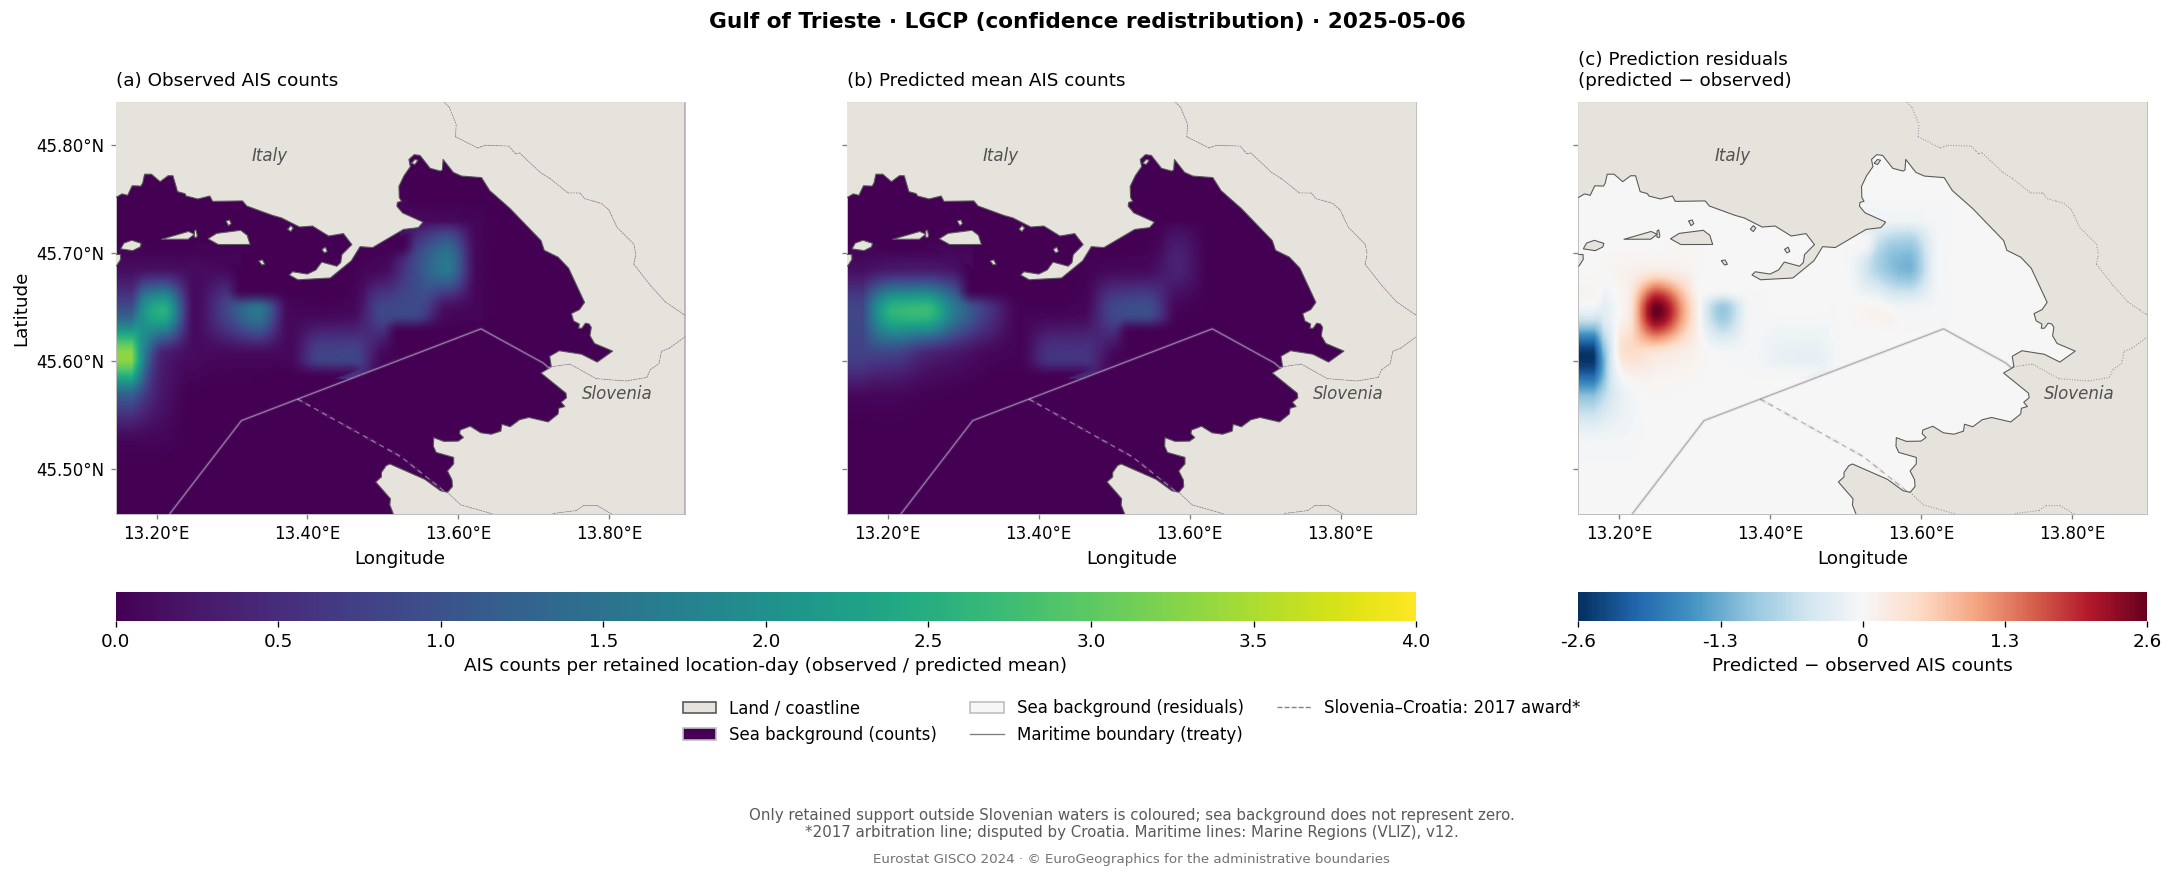

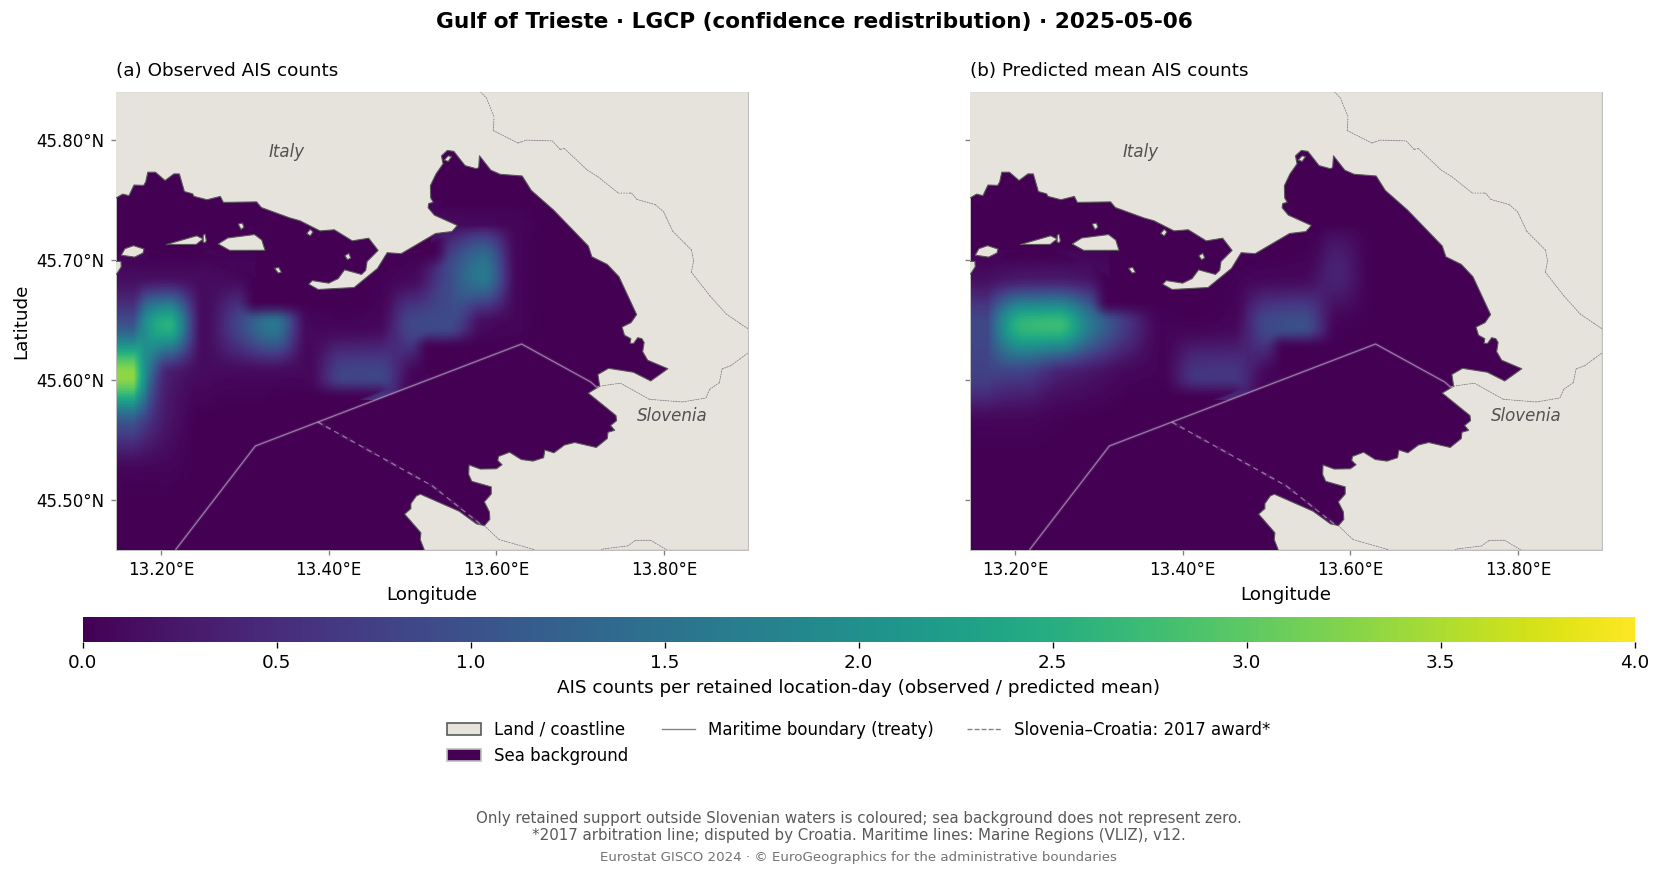

Rendered both previews in 6.66 s.


In [113]:
show_line = False  # False hides the dashed model-coverage boundary.
show_maritime_lines = True  # Independent of show_line (the grid-support boundary).
mask_slovenian_waters = True  # Display-only: keep Slovenian waters as sea background.

smooth_sea_edges = True  # False restores the original sharp offshore grid edges.
sea_edge_fade_km = 2.0  # Inward transition width; larger = softer/wider.

STYLE = dict(
    figsize=(18, 7.2), preview_dpi=120, font_size=11,
    count_cmap="viridis", residual_cmap="RdBu_r", count_vmax=None,
    coast_color="0.35", land_color="#e6e3dc", sea_color="count_min",
    residual_sea_color="residual_zero",  # Match the residual colormap at zero exactly.
    support_color="0.45", show_line=show_line,
    show_country_labels=True, show_country_borders=True,
    show_maritime_lines=show_maritime_lines,
    mask_slovenian_waters=mask_slovenian_waters,
    smooth_sea_edges=smooth_sea_edges, sea_edge_fade_km=sea_edge_fade_km,
    maritime_color="#d8dce2", residual_maritime_color="0.45",
    maritime_linewidth=0.8, maritime_alpha=0.5,
    show_support=False, support_size=12, show_grid=False,
    figure_title="Gulf of Trieste · {method} · {date}",
    panel_titles=["(a) Observed AIS counts", "(b) Predicted mean AIS counts",
                  "(c) Prediction residuals\n(predicted − observed)"],
)

started = perf_counter()
if "fig" in globals():
    plt.close(fig)
fig, axes = draw_map(prepared, STYLE)
display(fig)
plt.close(fig)  # Prevent duplicate automatic inline output; fig remains available for export.
# A separate two-map figure from the same cell, using the same date, surfaces,
# colormap and count limits as the three-panel figure above.
# Reserve an extra line below the daily comparison title in constrained layout.
COMPARISON_STYLE = dict(STYLE, figsize=(14, 7.2), figure_title=STYLE["figure_title"] + "\n")
if "comparison_fig" in globals():
    plt.close(comparison_fig)
comparison_fig, comparison_axes = draw_map(prepared, COMPARISON_STYLE, include_residual=False)
display(comparison_fig)
plt.close(comparison_fig)
print(f"Rendered both previews in {perf_counter() - started:.2f} s.")

## Aggregated interval comparison
Set **both** `INTERVAL_START` and `INTERVAL_END` below (inclusive). Defaults cover the full **5–11 May 2025** window. For the November model, use **2025-11-03** through **2025-11-09**. Shorter contiguous intervals within either run also work.

For each retained cell, **sum the original observed daily counts and predicted daily means over the interval, then interpolate those totals** using the same settings as the daily comparison. The predicted total is an expected count summed across days; these totals do not represent unique vessels across the interval. Both maps share one count scale and the title shows both endpoints and the number of days.

The cell checks that every requested day and spatial cell is present and that the interval uses exactly one experiment run. It never treats missing days as zero or mixes the May and November models. This preview has its own variables and leaves the daily selection and export unchanged.

This comparison reuses the same GIS geography and retained-support mask as the single-day maps.

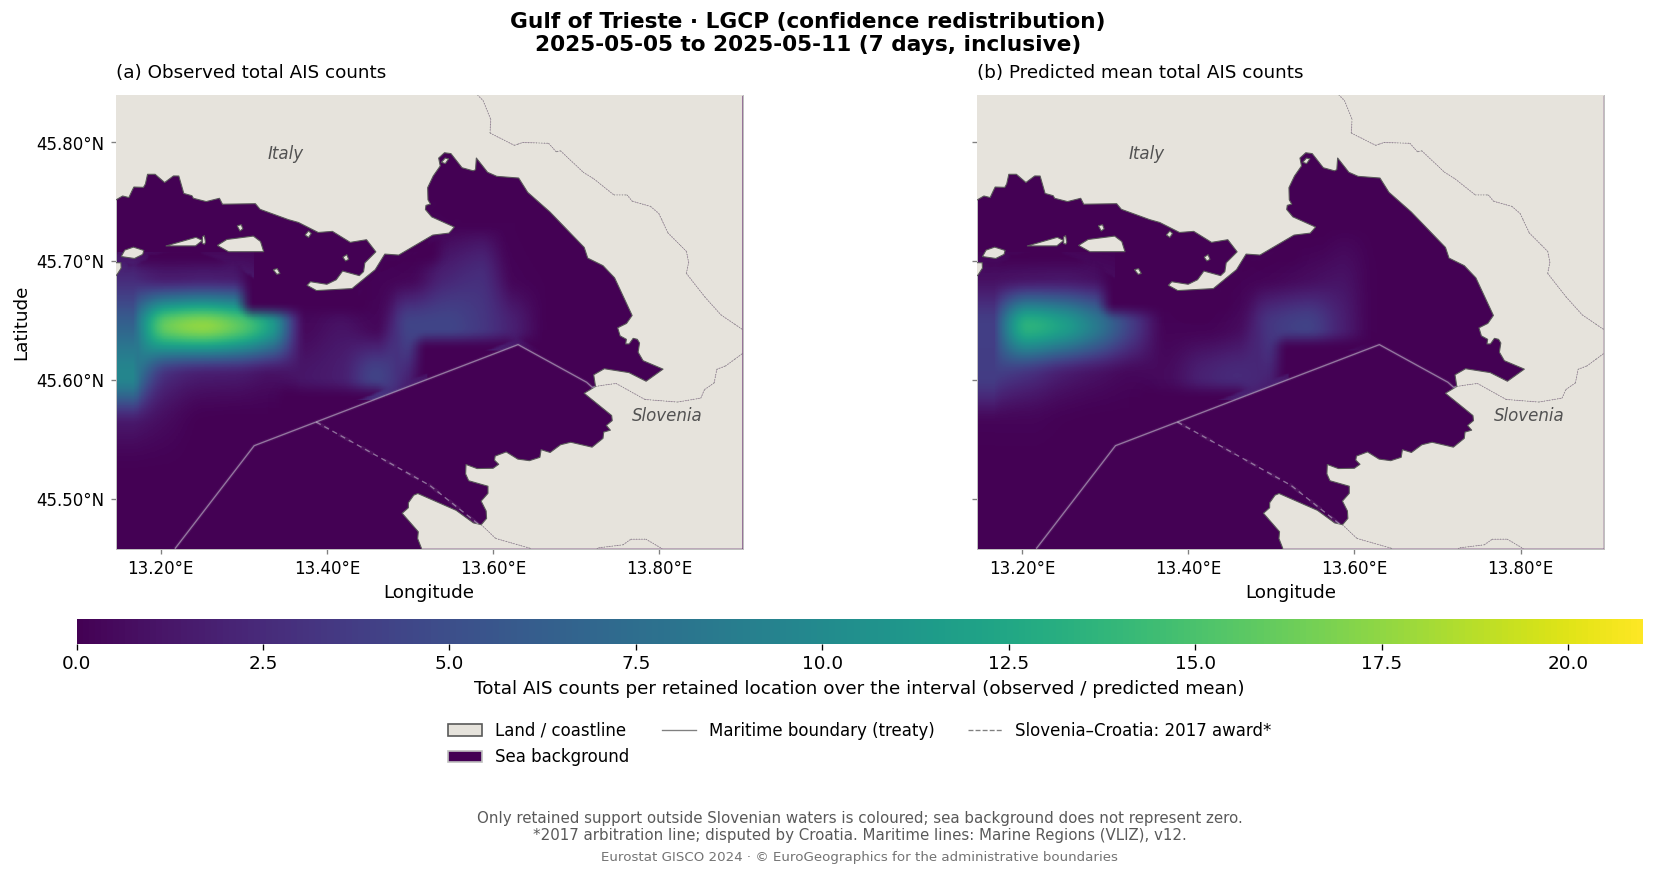

Interval: 2025-05-05 to 2025-05-11 (7 days, inclusive)
Source run: 2024+2025_may_5_11_confidence_redistribute_original_setting_20260920-180732
Summed 7 days across 49 cells: observed=127, predicted=76.067.


In [114]:
INTERVAL_START = "2025-05-05"
INTERVAL_END = "2025-05-11"


def prepare_interval_map(data, geography, method, start, end, **surface_settings):
    start, end = pd.Timestamp(start).normalize(), pd.Timestamp(end).normalize()
    if pd.isna(start) or pd.isna(end) or start > end:
        raise ValueError("Provide valid interval endpoints with start <= end.")
    days = pd.date_range(start, end, freq="D")
    selected = data.loc[(data["method"] == method) & data["date"].between(start, end)].copy()
    missing = days.difference(pd.DatetimeIndex(selected["date"].unique()))
    if len(missing):
        raise ValueError("The interval contains days without saved predictions: "
                         + ", ".join(missing.strftime("%Y-%m-%d")))
    if selected["source_run"].nunique() != 1:
        raise ValueError("Choose an interval within one run: May 5–11 or November 3–9, 2025.")
    cell_columns = ["longitude", "latitude"]
    if selected.duplicated(["date", *cell_columns]).any():
        raise ValueError("Duplicate cell-day rows cannot be aggregated.")
    coverage = selected.groupby(cell_columns)["date"].nunique()
    if not coverage.eq(len(days)).all():
        raise ValueError("Every retained cell must have a prediction and observation on every interval day.")
    totals = selected.groupby(cell_columns, as_index=False).agg(
        y_true=("y_true", "sum"), y_pred=("y_pred", "sum"),
        source_run=("source_run", "first"), source_csv=("source_csv", "first"),
    )
    totals["method"] = method
    # prepare_map uses a date to select rows; here all rows represent one interval.
    totals["date"] = start
    result = prepare_map(totals, geography, method, start, **surface_settings)
    result["interval_start"] = start.strftime("%Y-%m-%d")
    result["interval_end"] = end.strftime("%Y-%m-%d")
    result["n_days"] = len(days)
    result["aggregation"] = "sum of original cell-day values before interpolation"
    result["date"] = f"{result['interval_start']} to {result['interval_end']} ({len(days)} days, inclusive)"
    result["rows"]["interval_start"] = result["interval_start"]
    result["rows"]["interval_end"] = result["interval_end"]
    result["rows"] = result["rows"].drop(columns="date")
    return result


interval_prepared = prepare_interval_map(
    predictions, geography, METHOD, INTERVAL_START, INTERVAL_END, **SURFACE
)
INTERVAL_STYLE = dict(
    COMPARISON_STYLE,
    count_label="Total AIS counts per retained location over the interval (observed / predicted mean)",
    count_vmax=None,  # Auto-scale the totals; daily count limits need not fit this interval.
    figure_title="Gulf of Trieste · {method}\n{date}",
    panel_titles=["(a) Observed total AIS counts", "(b) Predicted mean total AIS counts"],
)
if "interval_fig" in globals():
    plt.close(interval_fig)
interval_fig, interval_axes = draw_map(interval_prepared, INTERVAL_STYLE, include_residual=False)
display(interval_fig)
plt.close(interval_fig)
print("Interval:", interval_prepared["date"])
print("Source run:", interval_prepared["rows"]["source_run"].iloc[0])
print(f"Summed {interval_prepared['n_days']} days across {len(interval_prepared['rows'])} cells: "
      f"observed={interval_prepared['rows']['y_true'].sum():g}, "
      f"predicted={interval_prepared['rows']['y_pred'].sum():.3f}.")

## Export
Set `SAVE_FIGURE=True` and rerun this cell when ready. The figure is rebuilt from the current `prepared` data and `STYLE`, then saved with a common filename in a dedicated design folder. Set `EXPORT_TAG` to keep multiple variants; reusing a tag replaces that variant's files. PNG is convenient for review, PDF/SVG preserve vector text and the outline with an embedded raster surface.

The companion CSV contains the original cell counts and **raw** residuals; the JSON records sources, interpolation, style, and actual colour limits. The caption describes the displayed residual correctly. No existing experiment plots are overwritten.

In [115]:
SAVE_FIGURE = False
EXPORT_TAG = "v01"
EXPORT_FORMATS = ("png", "pdf", "svg")
EXPORT_DPI = 300

if SAVE_FIGURE:
    if not EXPORT_TAG or any(c not in "abcdefghijklmnopqrstuvwxyzABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789_-" for c in EXPORT_TAG):
        raise ValueError("Use letters, numbers, underscores, and hyphens in EXPORT_TAG.")
    if not set(EXPORT_FORMATS) <= {"png", "pdf", "svg"}:
        raise ValueError("Choose export formats from png, pdf, svg.")
    EXPORT_DIR.mkdir(parents=True, exist_ok=True)
    stem = f"gulf_map_{prepared['method']}_{prepared['date']}_{EXPORT_TAG}"
    export_fig, export_axes = draw_map(prepared, STYLE)
    try:
        for suffix in EXPORT_FORMATS:
            path = EXPORT_DIR / f"{stem}.{suffix}"
            export_fig.savefig(path, dpi=EXPORT_DPI, bbox_inches="tight", facecolor="white")
            print(path)
        count_norm = export_axes[0].images[0].norm
        residual_norm = export_axes[2].images[0].norm
        metadata = {
            "method": prepared["method"], "date": prepared["date"],
            "source_csvs": sorted(prepared["rows"].source_csv.unique().tolist()),
            "source_runs": sorted(prepared["rows"].source_run.unique().tolist()),
            "coordinate_conversion": "inverse saved plotting metadata, then match to original grid within 0.0001 degrees",
            "grid_file": str(GRID_FILE.relative_to(PROJECT_ROOT)),
            "gis_file": str(GIS_FILE.relative_to(PROJECT_ROOT)),
            "geography_source": GEOGRAPHY_SOURCE,
            "maritime_source": MARITIME_SOURCE if STYLE.get("show_maritime_lines", True) else None,
            "italian_edge_smoothing_mask": MARITIME_SOURCE["italian_edge_smoothing_mask"] if STYLE.get("smooth_sea_edges", False) else None,
            "map_extent": prepared["geography"]["extent"],
            "slovenian_display_mask": MARITIME_SOURCE["slovenian_display_mask"] if STYLE.get("mask_slovenian_waters", True) else None,
            "support_definition": "union of retained cell footprints intersected with GIS water and map extent",
            "surface": prepared["surface_settings"], "style": STYLE,
            "count_limits": [count_norm.vmin, count_norm.vmax],
            "residual_limits": [residual_norm.vmin, residual_norm.vmax],
            "residual_definition": "displayed predicted surface minus displayed observed surface",
            "raw_residual_definition": "saved y_pred minus saved y_true",
            "export_dpi": EXPORT_DPI,
            "versions": {"matplotlib": mpl.__version__, "numpy": np.__version__, "pandas": pd.__version__},
        }
        (EXPORT_DIR / f"{stem}_settings.json").write_text(json.dumps(metadata, indent=2) + "\n")
        prepared["rows"].to_csv(EXPORT_DIR / f"{stem}_cells.csv", index=False)
        label = METHOD_LABELS.get(prepared["method"], prepared["method"])
        caption = (
            f"Spatial prediction example in the Gulf of Trieste for {prepared['date']} ({label}). "
            "(a) Observed AIS counts, (b) predicted mean AIS counts, and (c) prediction residuals "
            "(displayed predicted surface minus displayed observed surface). Observed and predicted "
            "maps share one colour scale; residuals use a diverging scale centred at zero. "
            "Maps share longitude–latitude coordinates, geographic extent, GIS coastline and retained-grid support mask. "
            + SUPPORT_NOTE + " Geographic context: Eurostat GISCO Countries 2024, 1:1 million. © EuroGeographics for the administrative boundaries. " +
            "The smooth surfaces visualize counts defined on the retained spatial cells, not continuous vessel density."
        )
        if STYLE.get("mask_slovenian_waters", True):
            caption += (" Slovenian waters (Marine Regions, MRGID 5692) are masked for display only; "
                        "sea background in this area does not represent zero counts. Original cell values are retained.")
        if STYLE.get("smooth_sea_edges", False):
            caption += (f" Offshore grid edges in Italian waters are opacity-feathered inward over {STYLE['sea_edge_fade_km']:g} km "
                        "for display only, using Marine Regions (VLIZ), MRGID 5682, CC BY 4.0. "
                        "Coastlines and maritime boundaries are protected; blended margin colours are not quantitative values. "
                        "Raw values and colour scales are unchanged.")
        if STYLE.get("show_maritime_lines", True):
            caption += (" Maritime lines: Marine Regions (VLIZ), World Maritime Boundaries v12 (2023), CC BY 4.0. "
                        "Italy's bilateral divisions use treaty lines; the Slovenia–Croatia line follows the "
                        "2017 arbitral award and is disputed by Croatia. Junction-regime limits are not shown.")
        (EXPORT_DIR / f"{stem}_caption.txt").write_text(caption + "\n")
        display(Markdown(caption))
    finally:
        plt.close(export_fig)
else:
    print("Preview only. Set SAVE_FIGURE=True to export the current design.")

Preview only. Set SAVE_FIGURE=True to export the current design.
